<a href="https://colab.research.google.com/github/MorganWilliams9/model-portfolio-dfm/blob/main/DFM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

downloading...
  ok   UK Equity      VUKE.L    2141 rows
  ok   Global Equity  SWDA.L    2141 rows
  ok   EM Equity      VFEM.L    2140 rows
  ok   Global Bonds   AGGG.L    2142 rows
  ok   UK Gilts       IGLT.L    2141 rows
  ok   Gold           SGLN.L    2142 rows
window: 2018-01-02 to 2026-06-25  (2141 days)


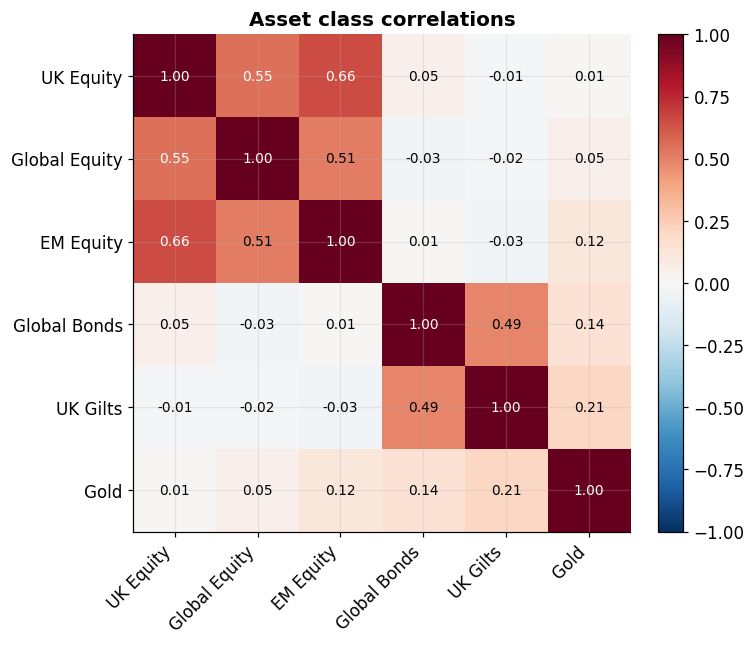

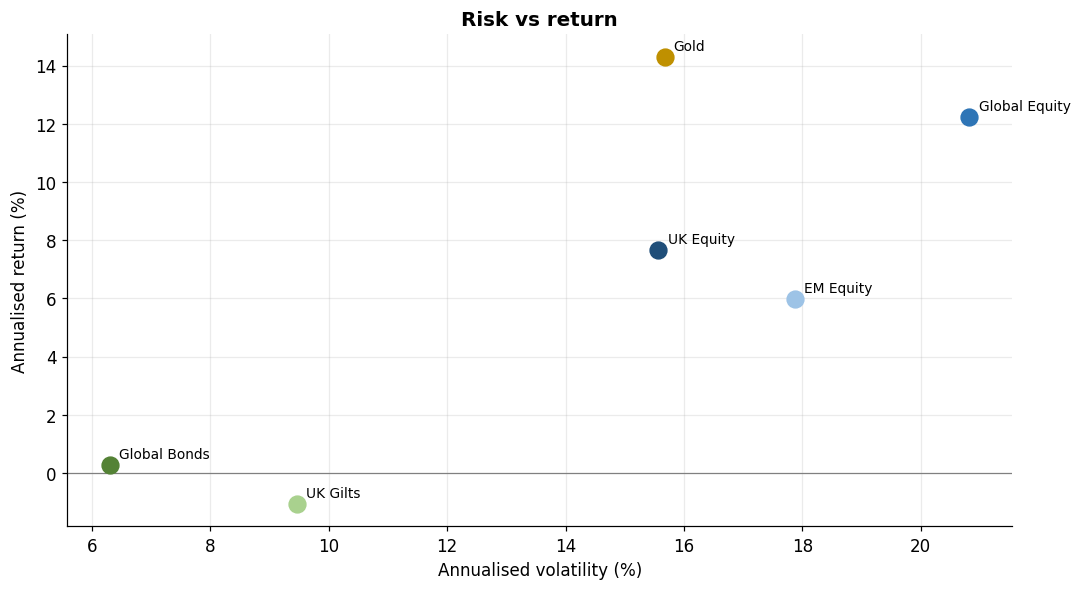

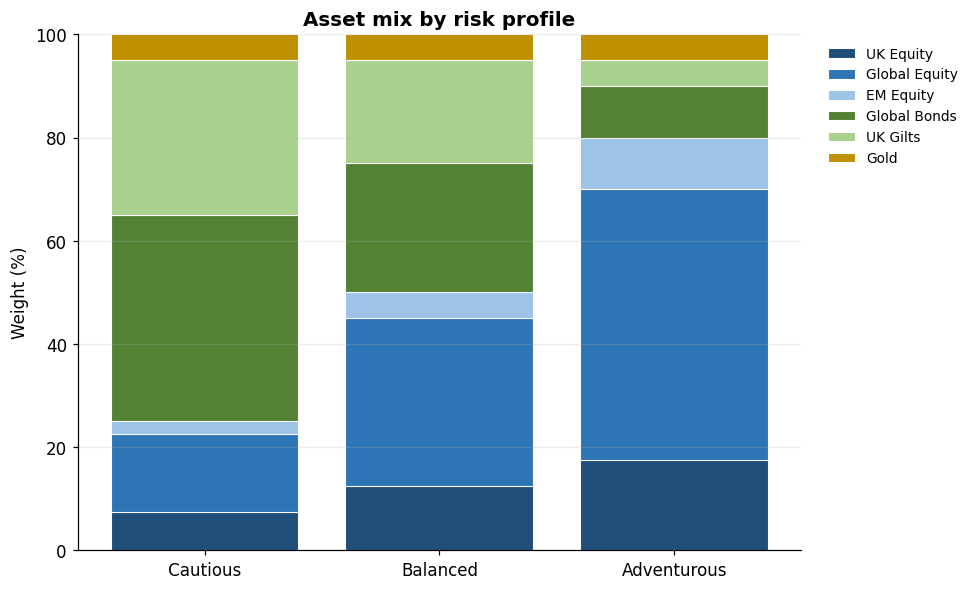

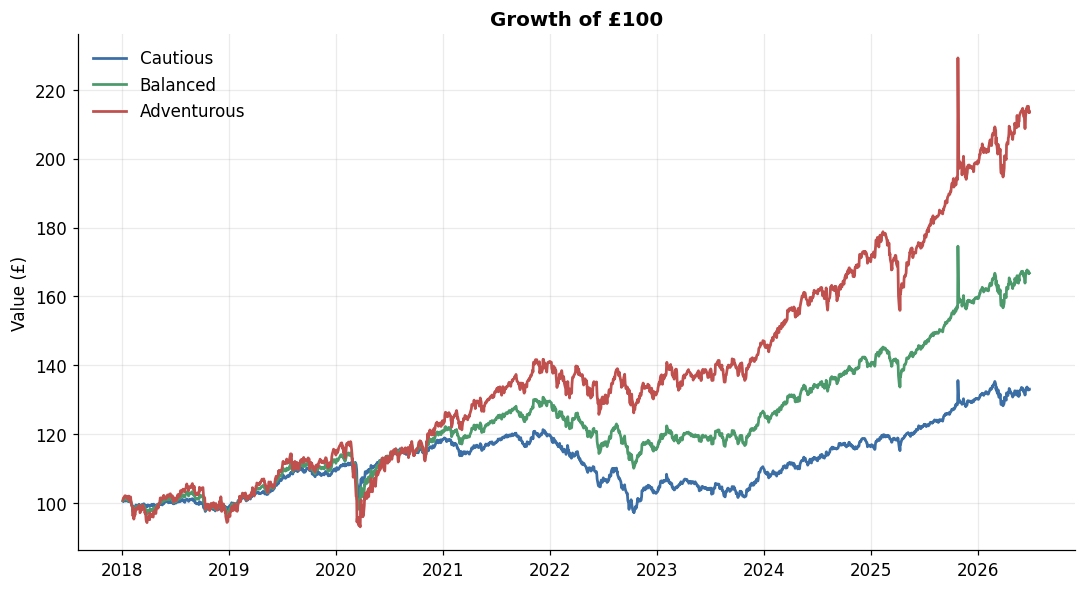

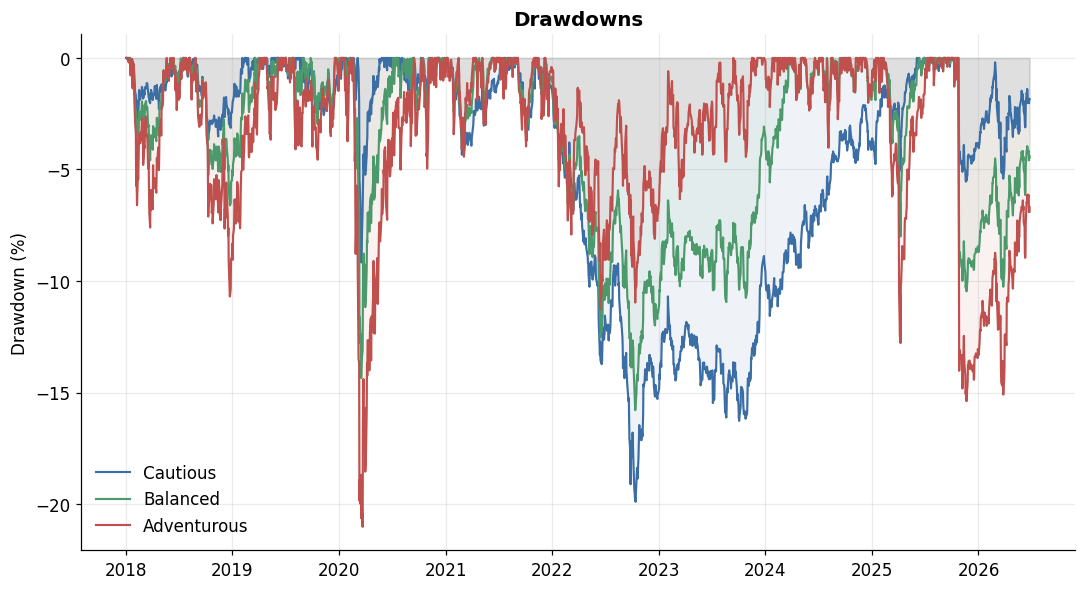

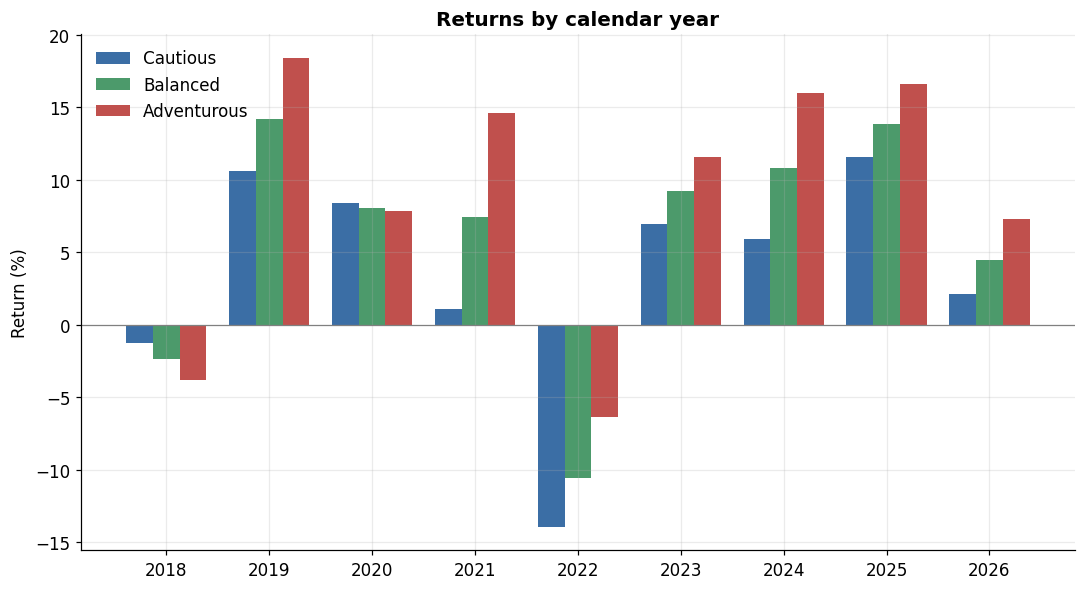

allocation     -6.00%
selection     -17.60%
interaction     2.42%
total_active  -21.18%


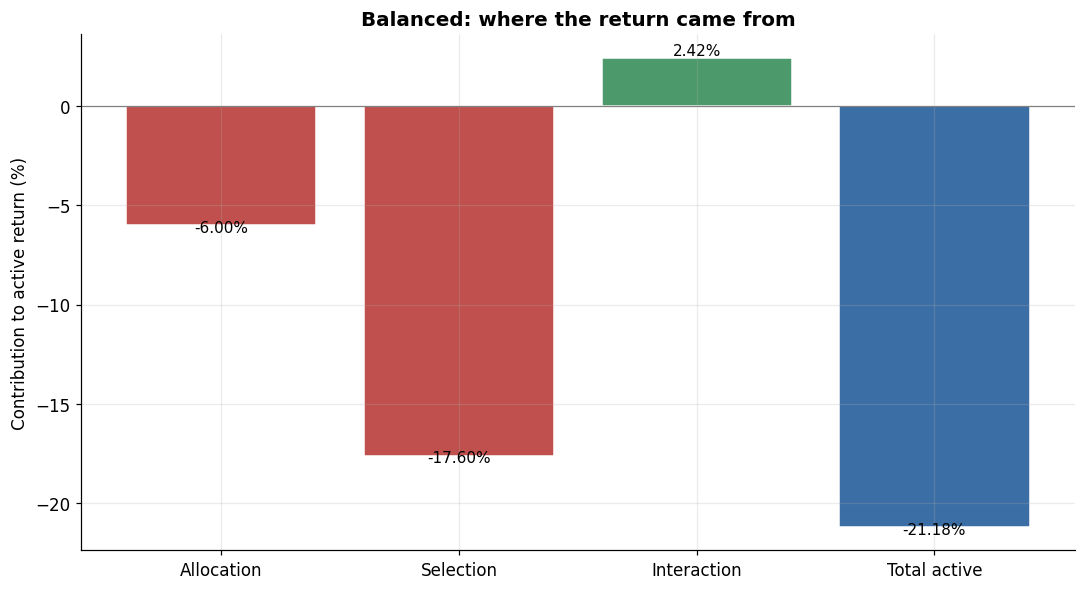

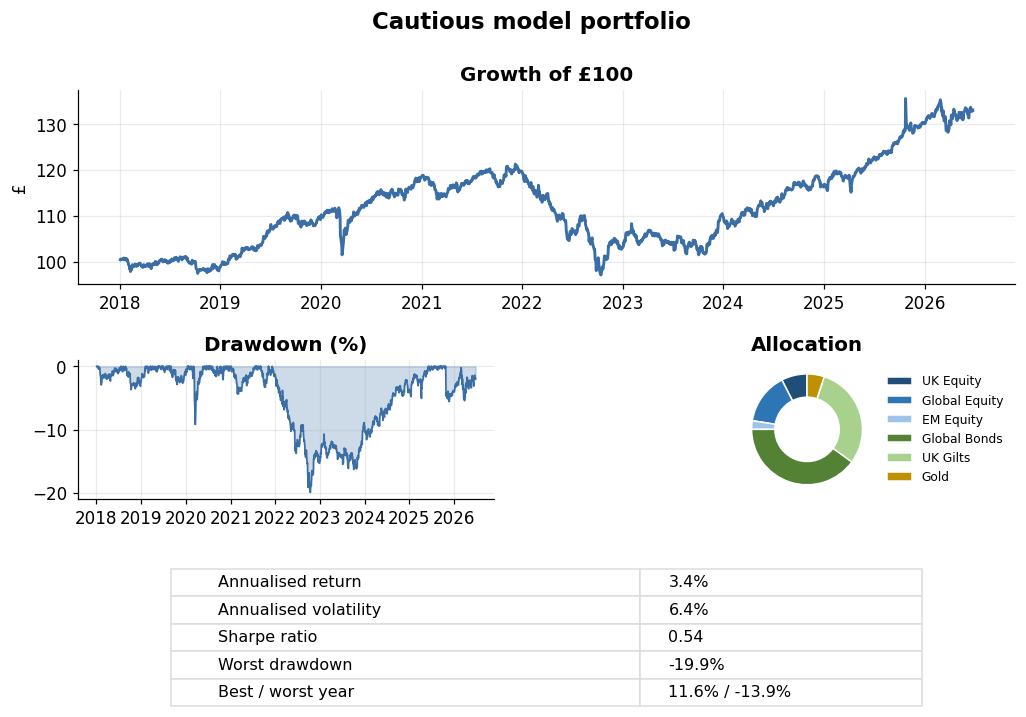

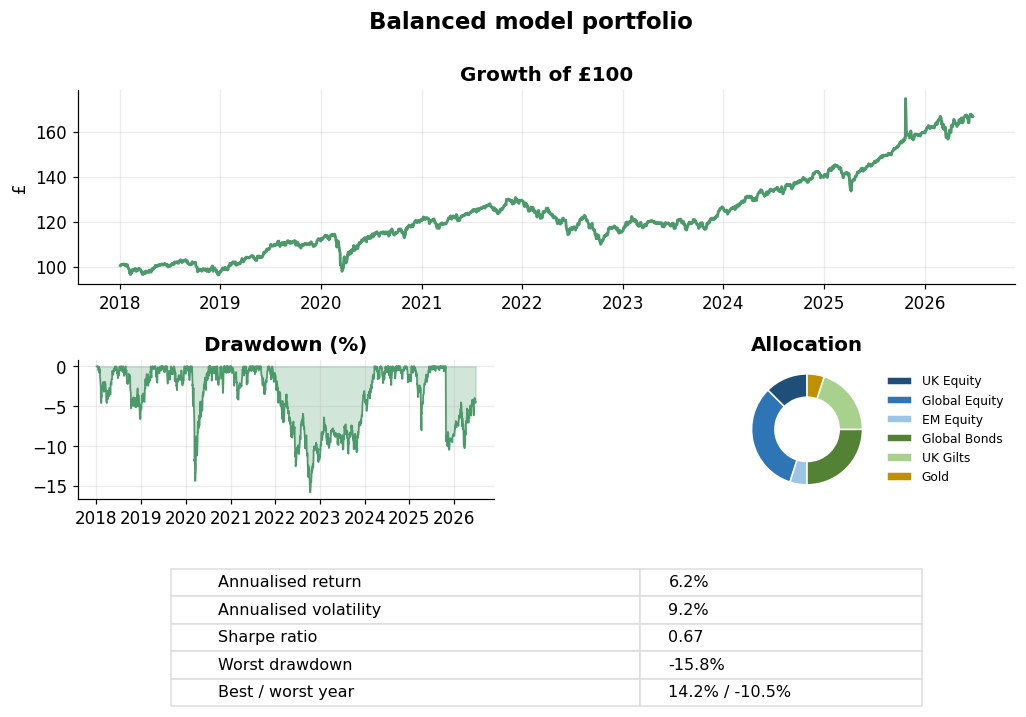

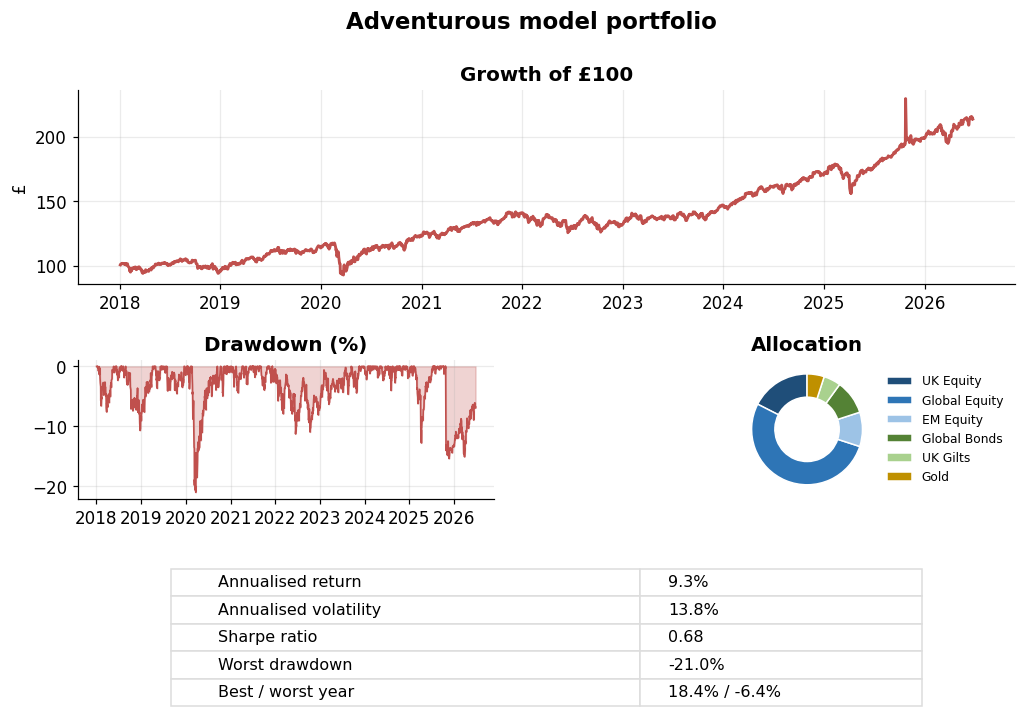

In [1]:
# %% [markdown]
# # Model Portfolio Tool
#
# Builds three risk-graded model portfolios from low-cost ETFs, backtests them
# with yearly rebalancing, and breaks down where the returns came from.
#
# Run the cells in order. Run the first one once to install yfinance.

# %% [markdown]
# ## Setup

# %%
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)

# %%
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except Exception as e:
    yf = None
    print("yfinance not ready, re-run the install cell.", e)

# --- config: change these and the rest follows ---

# one ETF per asset class (.L = London listed)
BUILDING_BLOCKS = {
    "UK Equity":     "VUKE.L",
    "Global Equity": "SWDA.L",
    "EM Equity":     "VFEM.L",
    "Global Bonds":  "AGGG.L",
    "UK Gilts":      "IGLT.L",
    "Gold":          "SGLN.L",
}

# weights per risk profile, in percent, each set sums to 100
MODEL_PORTFOLIOS = {
    "Cautious":    {"UK Equity": 7.5,  "Global Equity": 15.0, "EM Equity": 2.5,
                    "Global Bonds": 40.0, "UK Gilts": 30.0, "Gold": 5.0},
    "Balanced":    {"UK Equity": 12.5, "Global Equity": 32.5, "EM Equity": 5.0,
                    "Global Bonds": 25.0, "UK Gilts": 20.0, "Gold": 5.0},
    "Adventurous": {"UK Equity": 17.5, "Global Equity": 52.5, "EM Equity": 10.0,
                    "Global Bonds": 10.0, "UK Gilts": 5.0,  "Gold": 5.0},
}

START_DATE = "2018-01-01"
END_DATE = None
REBAL_FREQ = "YE"        # year-end; use "QE" for quarterly
REBAL_COST_BPS = 0.0     # turnover cost at rebalance, off by default
RISK_FREE = 0.0
TRADING_DAYS = 252

PALETTE = {"Cautious": "#3B6EA5", "Balanced": "#4C9A6B", "Adventurous": "#C0504D"}
ASSET_COLOURS = {
    "UK Equity": "#1F4E79", "Global Equity": "#2E75B6", "EM Equity": "#9DC3E6",
    "Global Bonds": "#548235", "UK Gilts": "#A9D18E", "Gold": "#BF9000",
}

plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "legend.frameon": False,
})

# %% [markdown]
# ## Functions

# %%
def _extract_close(data, ticker):
    # yfinance column layout varies by version, handle both shapes
    if data is None or len(data) == 0:
        raise ValueError("empty download")
    if isinstance(data.columns, pd.MultiIndex):
        close = data["Close"]
        if isinstance(close, pd.DataFrame):
            close = close[ticker] if ticker in close.columns else close.iloc[:, 0]
    else:
        close = data["Close"]
    return close.astype(float)


def clean_prices(raw, ffill_limit=5):
    prices = raw.sort_index()
    prices = prices[~prices.index.duplicated(keep="last")]
    prices = prices.ffill(limit=ffill_limit)   # fill short holiday gaps only
    prices = prices.dropna(how="any")          # keep the common window
    if prices.empty:
        raise ValueError("no overlapping dates across all assets")
    return prices


def to_returns(prices):
    return prices.pct_change().dropna(how="any")


def annual_return(rets):
    n_years = len(rets) / TRADING_DAYS
    if n_years <= 0:
        return np.nan
    return (1.0 + rets).prod() ** (1.0 / n_years) - 1.0


def annual_vol(rets):
    return rets.std() * np.sqrt(TRADING_DAYS)


def sharpe_ratio(rets, rf=RISK_FREE):
    vol = annual_vol(rets)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return (annual_return(rets) - rf) / vol


def drawdown_series(rets):
    cum = (1.0 + rets).cumprod()
    return cum / cum.cummax() - 1.0


def max_drawdown(rets):
    return drawdown_series(rets).min()


def sortino_ratio(rets, rf=RISK_FREE):
    downside = rets[rets < 0].std() * np.sqrt(TRADING_DAYS)   # downside only
    if downside == 0 or np.isnan(downside):
        return np.nan
    return (annual_return(rets) - rf) / downside


def calmar_ratio(rets):
    mdd = max_drawdown(rets)
    if mdd == 0 or np.isnan(mdd):
        return np.nan
    return annual_return(rets) / abs(mdd)


def calendar_year_returns(rets):
    return (1.0 + rets).resample("YE").prod() - 1.0


def performance_summary(rets, rf=RISK_FREE):
    return {
        "CAGR": annual_return(rets),
        "Volatility": annual_vol(rets),
        "Sharpe": sharpe_ratio(rets, rf),
        "Sortino": sortino_ratio(rets, rf),
        "Max Drawdown": max_drawdown(rets),
        "Calmar": calmar_ratio(rets),
        "Best Year": calendar_year_returns(rets).max(),
        "Worst Year": calendar_year_returns(rets).min(),
        "% Positive Months": (((1 + rets).resample("ME").prod() - 1) > 0).mean(),
    }


def backtest_portfolio(returns_df, weights, rebalance_freq=REBAL_FREQ, cost_bps=REBAL_COST_BPS):
    # set target weights, let them drift with the market, reset on rebalance dates
    assets = list(weights.keys())
    missing = [a for a in assets if a not in returns_df.columns]
    if missing:
        raise KeyError(f"weights use assets not in the data: {missing}")

    w_target = np.array([weights[a] for a in assets], dtype=float)
    w_target = w_target / w_target.sum()
    R = returns_df[assets].to_numpy()
    idx = returns_df.index
    rebal_dates = set(returns_df.resample(rebalance_freq).last().index)
    cost = cost_bps / 1e4

    # day loop, fine for a few assets over a few thousand days
    port = np.empty(len(idx))
    w = w_target.copy()
    for t in range(len(idx)):
        r = R[t]
        port[t] = float(np.dot(w, r))
        w = w * (1.0 + r)              # drift
        s = w.sum()
        if s > 0:
            w = w / s
        if idx[t] in rebal_dates:
            port[t] -= np.abs(w_target - w).sum() * cost
            w = w_target.copy()        # rebalance
    return pd.Series(port, index=idx, name="portfolio")


def compound_return(rets):
    return (1.0 + rets).prod() - 1.0


def blended_bucket_return(returns_df, sleeve_weights):
    # total return of a group of sleeves at their internal weights
    assets = list(sleeve_weights.keys())
    w = np.array([sleeve_weights[a] for a in assets], dtype=float)
    w = w / w.sum()
    daily = returns_df[assets].to_numpy() @ w
    return float(np.prod(1.0 + daily) - 1.0)


def brinson_attribution(wP, wB, rP, rB):
    # split active return into allocation, selection, interaction (sums to total)
    buckets = list(wB.keys())
    rB_total = sum(wB[b] * rB[b] for b in buckets)
    allocation = sum((wP[b] - wB[b]) * (rB[b] - rB_total) for b in buckets)
    selection = sum(wB[b] * (rP[b] - rB[b]) for b in buckets)
    interaction = sum((wP[b] - wB[b]) * (rP[b] - rB[b]) for b in buckets)
    return {"allocation": allocation, "selection": selection, "interaction": interaction,
            "total_active": allocation + selection + interaction}

# %% [markdown]
# ## Get the data

# %%
def download_prices(blocks, start=START_DATE, end=END_DATE, retries=3):
    # pull adjusted close per ticker, retry a few times, skip any that fail
    if yf is None:
        raise RuntimeError("run the install cell first")
    series, failed = {}, []
    for name, ticker in blocks.items():
        for attempt in range(1, retries + 1):
            try:
                raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
                series[name] = _extract_close(raw, ticker)
                print(f"  ok   {name:<14} {ticker:<8} {len(series[name]):>5} rows")
                break
            except Exception as exc:
                if attempt == retries:
                    failed.append(name)
                    print(f"  FAIL {name:<14} {ticker:<8} {exc}")
    if not series:
        raise RuntimeError("no data downloaded, check connection or tickers")
    if failed:
        print("dropped:", failed)
    return pd.DataFrame(series)

print("downloading...")
raw_prices = download_prices(BUILDING_BLOCKS)

# %% [markdown]
# ## Clean and turn into returns

# %%
prices = clean_prices(raw_prices)
returns = to_returns(prices)
print(f"window: {prices.index.min().date()} to {prices.index.max().date()}  ({len(returns)} days)")
returns.head()

# %% [markdown]
# ## Look at the building blocks

# %%
block_stats = pd.DataFrame({name: performance_summary(returns[name]) for name in returns.columns}).T
fmt = block_stats.copy()
for c in ["CAGR", "Volatility", "Max Drawdown", "Best Year", "Worst Year", "% Positive Months"]:
    fmt[c] = (fmt[c] * 100).round(1).astype(str) + "%"
for c in ["Sharpe", "Sortino", "Calmar"]:
    fmt[c] = fmt[c].round(2)
fmt

# %%
# bonds and gold move differently to equities, which is why they earn a place
corr = returns.corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black", fontsize=9)
ax.set_title("Asset class correlations")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# %%
fig, ax = plt.subplots()
for name in returns.columns:
    x, y = annual_vol(returns[name]) * 100, annual_return(returns[name]) * 100
    ax.scatter(x, y, s=120, color=ASSET_COLOURS.get(name, "#444"), zorder=3)
    ax.annotate(name, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("Annualised return (%)")
ax.set_title("Risk vs return")
ax.axhline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.show()

# %% [markdown]
# ## Build the portfolios

# %%
portfolio_returns = pd.DataFrame({
    name: backtest_portfolio(returns, w) for name, w in MODEL_PORTFOLIOS.items()
})

# %%
profiles = list(MODEL_PORTFOLIOS.keys())
fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(profiles))
for asset in BUILDING_BLOCKS:
    vals = np.array([MODEL_PORTFOLIOS[p].get(asset, 0) for p in profiles], dtype=float)
    ax.bar(profiles, vals, bottom=bottom, label=asset,
           color=ASSET_COLOURS.get(asset, "#999"), edgecolor="white", linewidth=0.7)
    bottom += vals
ax.set_ylabel("Weight (%)"); ax.set_ylim(0, 100)
ax.set_title("Asset mix by risk profile")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

# %%
growth = 100 * (1 + portfolio_returns).cumprod()
fig, ax = plt.subplots()
for name in growth.columns:
    ax.plot(growth.index, growth[name], label=name, color=PALETTE[name], lw=1.8)
ax.set_title("Growth of £100")
ax.set_ylabel("Value (£)")
ax.legend()
plt.tight_layout(); plt.show()

# %% [markdown]
# ## Backtest and stress test

# %%
summary = pd.DataFrame({name: performance_summary(portfolio_returns[name]) for name in portfolio_returns.columns}).T
sfmt = summary.copy()
for c in ["CAGR", "Volatility", "Max Drawdown", "Best Year", "Worst Year", "% Positive Months"]:
    sfmt[c] = (sfmt[c] * 100).round(1).astype(str) + "%"
for c in ["Sharpe", "Sortino", "Calmar"]:
    sfmt[c] = sfmt[c].round(2)
sfmt

# %%
fig, ax = plt.subplots()
for name in portfolio_returns.columns:
    dd = drawdown_series(portfolio_returns[name]) * 100
    ax.plot(dd.index, dd, label=name, color=PALETTE[name], lw=1.4)
    ax.fill_between(dd.index, dd, 0, color=PALETTE[name], alpha=0.08)
ax.set_title("Drawdowns")
ax.set_ylabel("Drawdown (%)"); ax.legend()
plt.tight_layout(); plt.show()

# %%
cal = calendar_year_returns(portfolio_returns) * 100
cal.index = cal.index.year
fig, ax = plt.subplots()
x = np.arange(len(cal)); width = 0.26
for i, name in enumerate(cal.columns):
    ax.bar(x + (i - 1) * width, cal[name], width, label=name, color=PALETTE[name])
ax.set_xticks(x); ax.set_xticklabels(cal.index)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Return (%)"); ax.set_title("Returns by calendar year")
ax.legend()
plt.tight_layout(); plt.show()

# %% [markdown]
# ## Attribution
#
# Balanced portfolio against a 60/40 benchmark, split into allocation and
# selection. Selection comes out near zero because the holdings are trackers.

# %%
BUCKETS = {
    "Equity": ["UK Equity", "Global Equity", "EM Equity"],
    "Bonds": ["Global Bonds", "UK Gilts"],
    "Alternatives": ["Gold"],
}
BENCH_WEIGHTS = {"Equity": 0.60, "Bonds": 0.40, "Alternatives": 0.00}
BENCH_PROXY = {"Equity": "Global Equity", "Bonds": "Global Bonds", "Alternatives": "Gold"}

w = MODEL_PORTFOLIOS["Balanced"]
wP, rP, rB = {}, {}, {}
for bucket, sleeves in BUCKETS.items():
    wP[bucket] = sum(w[s] for s in sleeves) / 100.0
    rP[bucket] = blended_bucket_return(returns, {s: w[s] for s in sleeves})
    rB[bucket] = compound_return(returns[BENCH_PROXY[bucket]])

attrib = brinson_attribution(wP, BENCH_WEIGHTS, rP, rB)
for k, v in attrib.items():
    print(f"{k:<13} {v*100:6.2f}%")

# %%
labels = ["Allocation", "Selection", "Interaction", "Total active"]
vals = [attrib["allocation"] * 100, attrib["selection"] * 100,
        attrib["interaction"] * 100, attrib["total_active"] * 100]
colours = ["#4C9A6B" if v >= 0 else "#C0504D" for v in vals[:-1]] + ["#3B6EA5"]
fig, ax = plt.subplots()
ax.bar(labels, vals, color=colours, edgecolor="white")
for i, v in enumerate(vals):
    ax.text(i, v + (0.15 if v >= 0 else -0.35), f"{v:.2f}%", ha="center", fontsize=10)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Contribution to active return (%)")
ax.set_title("Balanced: where the return came from")
plt.tight_layout(); plt.show()

# %% [markdown]
# ## Client report

# %%
def build_tearsheet(profile):
    r = portfolio_returns[profile]
    g = 100 * (1 + r).cumprod()
    dd = drawdown_series(r) * 100
    stats = performance_summary(r)
    col = PALETTE[profile]

    fig = plt.figure(figsize=(11, 7.2))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.4, 1.0, 0.9], hspace=0.5, wspace=0.25)
    fig.suptitle(f"{profile} model portfolio", fontsize=15, fontweight="bold", y=0.98)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(g.index, g, color=col, lw=1.9); ax1.set_title("Growth of £100"); ax1.set_ylabel("£")

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.fill_between(dd.index, dd, 0, color=col, alpha=0.25)
    ax2.plot(dd.index, dd, color=col, lw=1.1); ax2.set_title("Drawdown (%)")

    ax3 = fig.add_subplot(gs[1, 1])
    sleeves = list(MODEL_PORTFOLIOS[profile].keys())
    vals = [MODEL_PORTFOLIOS[profile][s] for s in sleeves]
    ax3.pie(vals, colors=[ASSET_COLOURS.get(s, "#999") for s in sleeves],
            startangle=90, wedgeprops=dict(width=0.42, edgecolor="white"))
    ax3.set_title("Allocation")
    ax3.legend(sleeves, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)

    ax4 = fig.add_subplot(gs[2, :]); ax4.axis("off")
    rows = [
        ("Annualised return", f"{stats['CAGR']*100:.1f}%"),
        ("Annualised volatility", f"{stats['Volatility']*100:.1f}%"),
        ("Sharpe ratio", f"{stats['Sharpe']:.2f}"),
        ("Worst drawdown", f"{stats['Max Drawdown']*100:.1f}%"),
        ("Best / worst year", f"{stats['Best Year']*100:.1f}% / {stats['Worst Year']*100:.1f}%"),
    ]
    tbl = ax4.table(cellText=rows, colWidths=[0.5, 0.3], cellLoc="left", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1, 1.5)
    for _, cell in tbl.get_celld().items():
        cell.set_edgecolor("#dddddd")
    plt.show()

for p in MODEL_PORTFOLIOS:
    build_tearsheet(p)

# %% [markdown]
# ## Notes
#
# History starts around 2018, set by the youngest ETF, so it covers the 2020 and
# 2022 falls but not earlier ones. Returns are before fees and tax, and
# rebalancing is free unless REBAL_COST_BPS is turned on. Some holdings are priced
# in dollars, so there is some unhedged currency in the returns.
